In [ ]:
# -----------------------------------------------------
# 1. SETUP & IMPORTS
# -----------------------------------------------------
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import os
import seaborn as snsls
#from google.colab import drive

# Mount Google Drive
#drive.mount('/content/drive', force_remount=True)

# -----------------------------------------------------
# 2. DATA PREPARATION
# -----------------------------------------------------

base_dir = 'C:/Users/jerwin/Documents/butterfly_photos/butterfly'

if not os.path.isdir(base_dir):
    print(f"Error: The directory '{base_dir}' does not exist.")
else:
    IMG_SIZE = (224, 224) # ResNet50 is trained on 224x224 images
    BATCH_SIZE = 32

    # Create datasets without preprocessing first
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        base_dir,
        label_mode='categorical',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        seed=123,
        validation_split=0.2,
        subset='training'
    )

    validation_dataset = tf.keras.utils.image_dataset_from_directory(
        base_dir,
        label_mode='categorical',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        seed=123,
        validation_split=0.2,
        subset='validation'
    )

    butterfly_species_names = train_dataset.class_names
    print("Found the following classes:", butterfly_species_names)
    print(f"Number of classes: {len(butterfly_species_names)}")

    # --- CHANGED: Use ResNet50's specific preprocessing function ---
    # This scales pixel values appropriately for the ResNet50 model.
    preprocess_input = tf.keras.applications.resnet50.preprocess_input

    train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
    validation_dataset = validation_dataset.map(lambda x, y: (preprocess_input(x), y))

    # Configure dataset for performance
    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
    validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

    # -----------------------------------------------------
    # 3. BUILD THE MODEL WITH RESNET50 BASE
    # -----------------------------------------------------

    # --- CHANGED: Load the ResNet50 model ---
    # We exclude its final classification layer (include_top=False).
    base_model = tf.keras.applications.ResNet50(input_shape=IMG_SIZE + (3,),
                                                 include_top=False,
                                                 weights='imagenet')

    # Freeze the convolutional base to prevent its weights from being updated
    base_model.trainable = False

    # Create the new model by adding our custom classifier on top of the frozen base
    model = tf.keras.Sequential([
        base_model,
        # Convert features to a single vector per image
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.2),
        # The final prediction layer for our classes
        tf.keras.layers.Dense(len(butterfly_species_names), activation='softmax')
    ])

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\n--- Model Summary (Transfer Learning with ResNet50) ---")
    model.summary()

    # -----------------------------------------------------
    # 4. TRAIN THE MODEL
    # -----------------------------------------------------
    print("\nStarting model training...")
    history = model.fit(
        train_dataset,
        epochs=10,
        validation_data=validation_dataset
    )
    print("Training finished.")
    
    # --- ADDED: Save the trained model ---
    model_save_path = 'model_Species.h5'
    model.save(model_save_path)
    print(f"Model successfully saved to: {model_save_path}")

    # -----------------------------------------------------
    # 5. GENERATE AND VISUALIZE CONFUSION MATRIX
    # -----------------------------------------------------
    print("\nGenerating confusion matrix...")

    true_labels = []
    predicted_labels = []

    for images, labels in validation_dataset:
        preds = model.predict(images, verbose=0)
        predicted_class_indices = np.argmax(preds, axis=1)
        true_class_indices = np.argmax(labels.numpy(), axis=1)

        predicted_labels.extend(predicted_class_indices)
        true_labels.extend(true_class_indices)

    cm = tf.math.confusion_matrix(labels=true_labels, predictions=predicted_labels).numpy()
    
    # 

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=butterfly_species_names,
                yticklabels=butterfly_species_names)

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    # --- CHANGED: Updated plot title ---
    plt.title('Confusion Matrix (ResNet50)')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

ModuleNotFoundError: No module named 'seaborn'

ModuleNotFoundError: No module named 'seaborn'


Evaluating model with sklearn metrics...


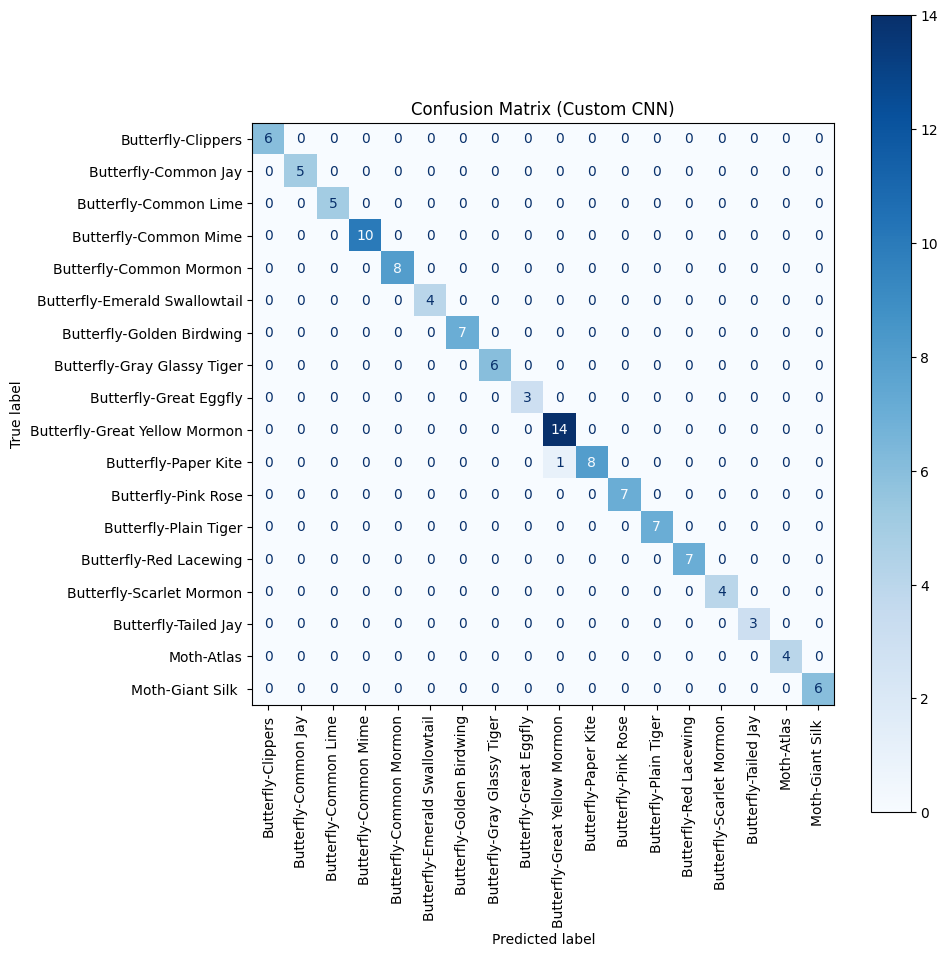

F1 Score (macro): 0.9948
F1 Score (weighted): 0.9912


In [ ]:
# 6. EVALUATE MODEL WITH SKLEARN METRICS
# -----------------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

print("\nEvaluating model with sklearn metrics...")

# Unbatch validation dataset for per-image prediction
y_true = []
y_pred = []

for image, label in validation_dataset.unbatch():
    img_array = tf.expand_dims(image, axis=0)  # Add batch dimension
    prediction = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(prediction, axis=1)[0]
    true_class = np.argmax(label.numpy())  # Convert one-hot to class index

    y_true.append(true_class)
    y_pred.append(predicted_class)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=butterfly_species_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix (Custom CNN)")
plt.tight_layout()
plt.show()

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")